# 📊 Stock Price Predictor - Data Exploration
### Understanding Apple (AAPL) stock trends through charts and statistics

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

# Load the CSV we saved in notebook 1
df = pd.read_csv("../data/raw/AAPL_raw.csv", header=[0,1])

# Check what columns we actually have
print("Columns:", df.columns.tolist())
print("First row:", df.iloc[0])

Columns: [('Price', 'Ticker'), ('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]
First row: Price   Ticker    2015-01-02
Close   AAPL       24.192612
High    AAPL       24.659514
Low     AAPL       23.754475
Open    AAPL       24.648449
Volume  AAPL       212818400
Name: 0, dtype: object


In [ ]:
# This gives us count, mean, min, max of every column
df.describe()

,Close,High,Low,Open,Volume
,AAPL,AAPL,AAPL,AAPL,AAPL
count,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03
mean,93.623190,94.532238,92.611390,93.535693,1.171162e+08
std,65.259577,65.850856,64.573238,65.177411,6.839222e+07
min,20.565872,20.868639,20.367818,20.488465,2.323470e+07
25%,35.138060,35.540947,34.779573,35.168903,7.108655e+07
50%,64.254364,64.603166,63.447175,64.013124,1.003845e+08
75%,149.941139,151.665577,147.929012,149.723862,1.426222e+08
max,257.375580,258.448740,255.994420,256.550862,6.488252e+08


In [6]:
# Load fresh with proper settings
df2 = pd.read_csv("../data/raw/AAPL_raw.csv", index_col=0, header=[0,1])
df2 = df2.iloc[1:]  # remove Ticker row
df2.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
df2.index = pd.to_datetime(df2.index)
df2 = df2.astype(float)

print("✅ Data ready!")
df2.head()

✅ Data ready!


,Close,High,Low,Open,Volume
2015-01-05,23.511055,24.042129,23.325180,23.962467,257142000.0
2015-01-06,23.513275,23.772173,23.152587,23.575233,263188400.0
2015-01-07,23.842979,23.942555,23.610634,23.721274,160423600.0
2015-01-08,24.759083,24.816616,24.053197,24.170477,237458000.0
2015-01-09,24.785633,25.060020,24.387327,24.931677,214798000.0


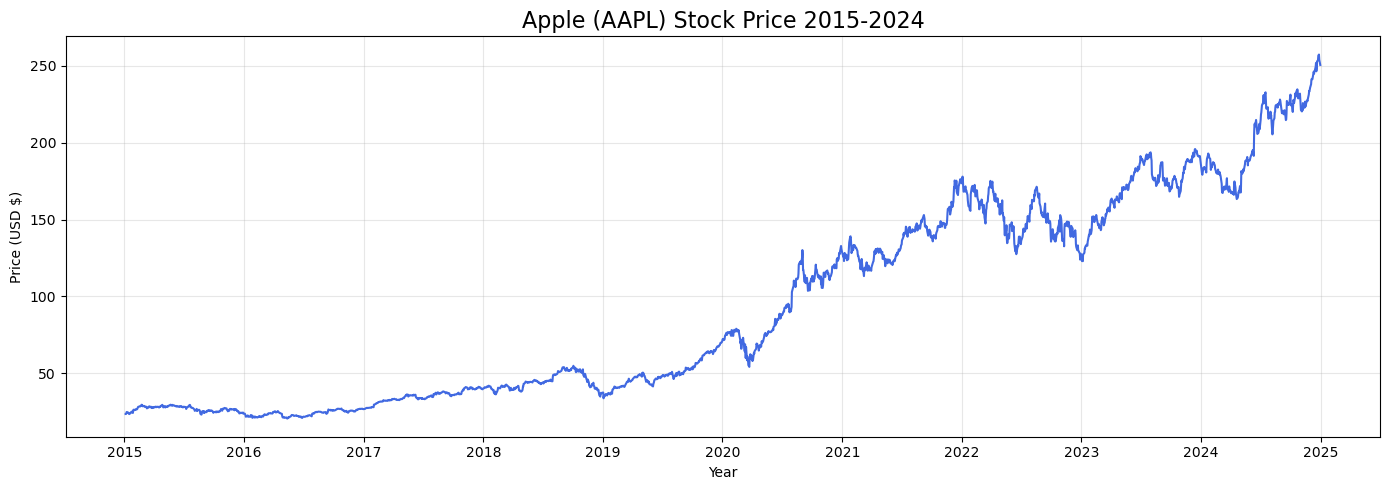

In [4]:
%matplotlib inline
plt.figure(figsize=(14,5))
plt.plot(df2.index, df2['Close'], color='royalblue', linewidth=1.5)
plt.title('Apple (AAPL) Stock Price 2015-2024', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price (USD $)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

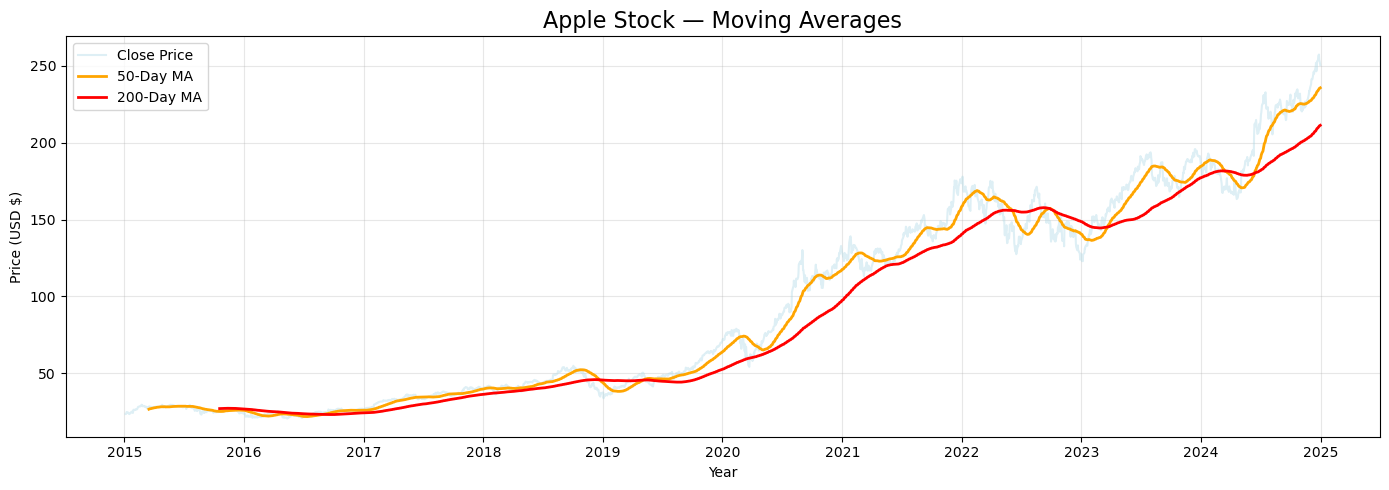

In [5]:
%matplotlib inline
df2['MA_50'] = df2['Close'].rolling(window=50).mean()
df2['MA_200'] = df2['Close'].rolling(window=200).mean()

plt.figure(figsize=(14,5))
plt.plot(df2.index, df2['Close'], label='Close Price', alpha=0.4, color='lightblue')
plt.plot(df2.index, df2['MA_50'], label='50-Day MA', color='orange', linewidth=2)
plt.plot(df2.index, df2['MA_200'], label='200-Day MA', color='red', linewidth=2)
plt.title('Apple Stock — Moving Averages', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price (USD $)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1400x400 with 0 Axes>

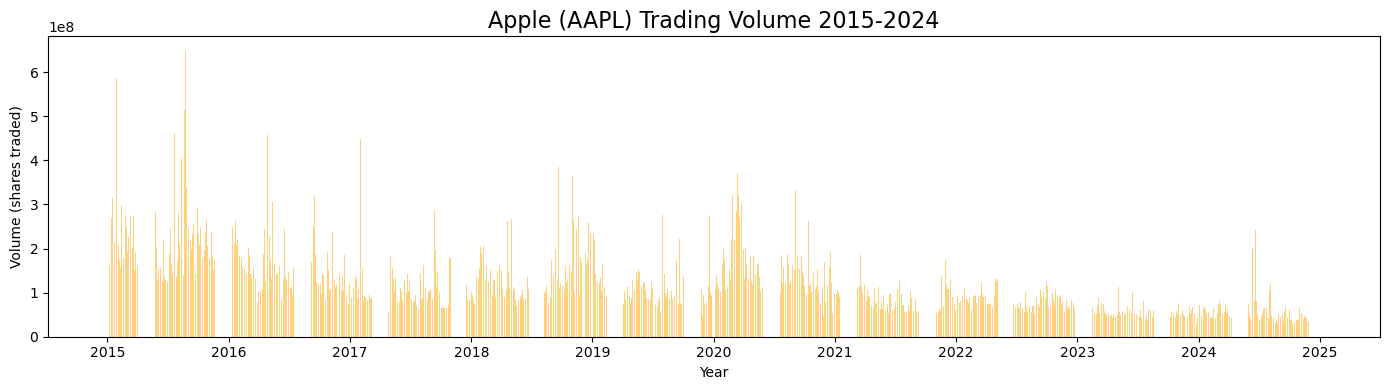

In [7]:
%matplotlib inline
plt.figure(figsize=(14,4))
plt.bar(df2.index, df2['Volume'], color='orange', alpha=0.5)
plt.title('Apple (AAPL) Trading Volume 2015-2024', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Volume (shares traded)')
plt.tight_layout()
plt.show()

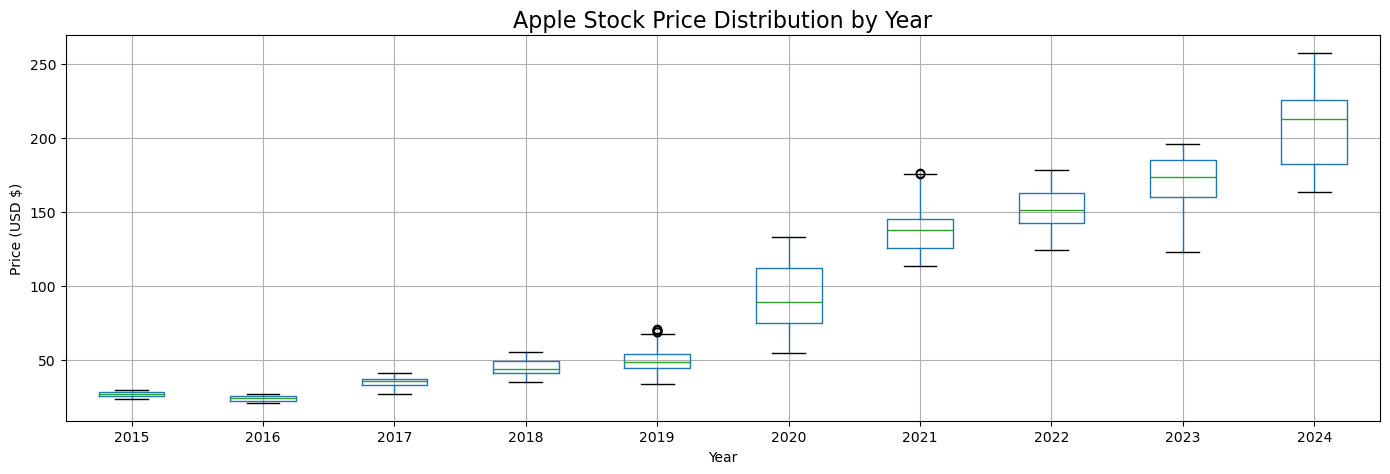

In [8]:
%matplotlib inline
df2['Year'] = df2.index.year
df2.boxplot(column='Close', by='Year', figsize=(14,5))
plt.title('Apple Stock Price Distribution by Year', fontsize=16)
plt.suptitle('')
plt.xlabel('Year')
plt.ylabel('Price (USD $)')
plt.tight_layout()
plt.show()

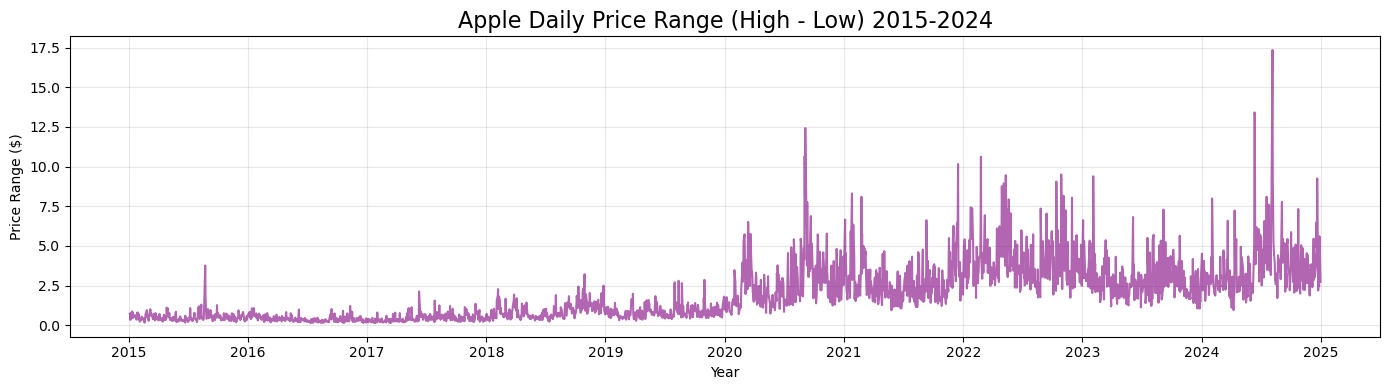

In [9]:
%matplotlib inline
df2['Daily_Range'] = df2['High'] - df2['Low']
plt.figure(figsize=(14,4))
plt.plot(df2.index, df2['Daily_Range'], color='purple', alpha=0.6)
plt.title('Apple Daily Price Range (High - Low) 2015-2024', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price Range ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
import os
os.makedirs("../data/processed", exist_ok=True)
df2.to_csv("../data/processed/AAPL_explored.csv")
print("✅ Saved to data/processed/AAPL_explored.csv")
print("🎉 Phase 2 - Data Exploration COMPLETE!")

✅ Saved to data/processed/AAPL_explored.csv
🎉 Phase 2 - Data Exploration COMPLETE!
